In [1]:
from langchain_openai import ChatOpenAI

from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['OPENAI_API_KEY']:
    print("OpenAI API Key is set.")
else:
    raise ValueError("OpenAI API Key is not set.")

OpenAI API Key is set.


In [2]:
llm = ChatOpenAI(model="gpt-5-nano")
llm.invoke("I want to know the meaning of water").content

'Here are the main ways to think about water. Tell me which angle you’re most interested in and I can go deeper.\n\n- Scientific meaning\n  - Water is a chemical substance with the formula H2O. It has two hydrogen atoms and one oxygen atom.\n  - It’s a liquid at standard room temperature, but it can be solid (ice) or gas (steam) under different conditions.\n  - Water is a polar molecule and a strong solvent, often called the “universal solvent” because many substances dissolve in it.\n  - It has key properties like high heat capacity, surface tension, and hydrogen bonding, which affect climate, biology, and everyday life.\n  - The water cycle describes how water moves through the earth (evaporation, condensation, precipitation, collection).\n\n- Everyday meaning\n  - Water is essential for life. All known living organisms need water to survive.\n  - It’s used for drinking, cooking, hygiene, farming, industry, and energy.\n  - Clean, safe drinking water is a basic public health need; po

In [3]:
from typing import TypedDict, List

class SocialMediaGraphState(TypedDict):
    topic: str
    instagram: str
    twitter: str
    facebook: str

In [4]:
def create_post_instagram(state: SocialMediaGraphState) -> SocialMediaGraphState:


    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate an Instagram post
    post = llm.invoke(f"Write an Instagram post about {topic}. Keep the tone casual and engaging.").content

    # Update the state with the generated post
    state['instagram'] = post

    return {'instagram' : post}

def create_post_twitter(state: SocialMediaGraphState) -> SocialMediaGraphState:


    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a Twitter post
    post = llm.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

    # Update the state with the generated post
    state['twitter'] = post

    return {'twitter' : post}


def create_post_facebook(state: SocialMediaGraphState) -> SocialMediaGraphState:


    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative.").content

    # Update the state with the generated post
    state['facebook'] = post

    return {'facebook' : post}

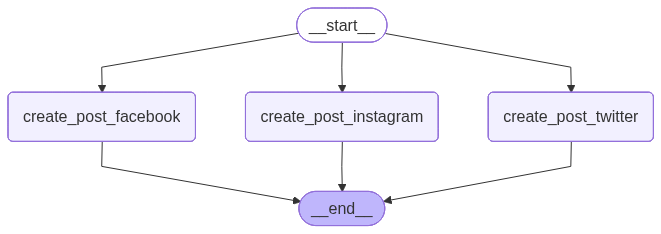

In [5]:
# create the graph, nodes and others

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

graph = StateGraph(SocialMediaGraphState)
graph.add_node("create_post_instagram", create_post_instagram)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_facebook", create_post_facebook)

# create parallel edges from START to all the above 3 nodes
graph.add_edge(START, "create_post_instagram")
graph.add_edge(START, "create_post_twitter")
graph.add_edge(START, "create_post_facebook")
graph.add_edge("create_post_instagram", END)
graph.add_edge("create_post_facebook", END)
graph.add_edge("create_post_twitter", END)

social_media_graph = graph.compile()

Image(social_media_graph.get_graph().draw_mermaid_png())


In [6]:
social_media_graph.invoke({"topic": "Covid-19"})

{'topic': 'Covid-19',
 'instagram': 'Hey IG, quick check-in about Covid-19: we’re still navigating it together, one day at a time. 🫶\n\n- Getting the updated vaccine when you can, masking in crowded indoor spaces, and keeping up with good hand hygiene still makes a difference. 💉😷🧼\n- Be kind to yourself and others—some folks are still at higher risk or dealing with long-term symptoms, and patience goes a long way. 💛\n- Look out for friends and trusted health guidance, and don’t hesitate to ask for help if you need it.\n\nWhat’s one small habit you’ve kept this year to stay safer and more comfy? Drop it below! 👇\n\n#Covid19 #Covid19Vaccination #PublicHealth #StaySafe #MaskUp #VaccineWorks #HealthAndWellness #CommunityCare #Wellbeing #CareForEachOther',
 'twitter': 'Covid-19 isn’t over. If you’re sick, test. If you’re eligible, get the updated booster. Mask up in crowded indoor spaces. Ventilate rooms. Stay informed with local guidance. Take care of yourself and others. #Covid19 #StaySaf

### Routing
